<a href="https://colab.research.google.com/github/martinthuriaux/Auto-Interp-Causal-Validation/blob/main/03_labelers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/martinthuriaux/CNN-Watch-vs-Do/blob/main/03_labelers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03 — The two labelers

We write a short text label for each of the 1,920 detectors, two ways:

- **Labeler A (all 1,920 units) — CLIP-Dissect.** Fix a 20k-word vocabulary. For each unit,
  find the word whose CLIP-similarity profile across the 31k probe images best tracks the
  unit's *firing* profile. Fast, consistent, but limited to the vocabulary.
- **Labeler B (400-unit subsample) — free-form VLM caption.** Show a small vision-language
  model the unit's 4x4 exemplar grid and ask for a 3-5 word label. Expressive but slower/
  noisier; the doing test will referee where A and B disagree.

**Reused artifacts:** the top-16 checkpoint + activation shards (01), the exemplar grids .
**New caches on Drive:** CLIP image embeddings (once), CLIP text embeddings (once), and the
two label tables.

## 0. Bootstrap + guards

In [ ]:
import os, json, hashlib, glob, time
from pathlib import Path
import numpy as np
import torch

assert torch.cuda.is_available(), "no GPU — Runtime > Change runtime type > T4"
device = "cuda"

from google.colab import drive
drive.mount('/content/drive')

PROJECT_ROOT = Path("/content/drive/MyDrive/cnn_watch_vs_do")
RESULTS = PROJECT_ROOT / "results"
DATA = Path("/content/data"); DATA.mkdir(exist_ok=True)
for sub in ["labels", "embeddings"]:
    (RESULTS / sub).mkdir(parents=True, exist_ok=True)

CONFIG = json.load(open(RESULTS / "config.json"))
CONFIG_HASH = hashlib.sha256(json.dumps(CONFIG, sort_keys=True).encode()).hexdigest()[:12]
STAGES = CONFIG["stages"]
STAGE_C = dict(zip(STAGES, CONFIG["expected_stage_channels"]))
print("config hash:", CONFIG_HASH)

index = json.load(open(RESULTS / "activations" / "image_index.json"))
N_IMAGES = len(index)
print("images:", N_IMAGES)


Mounted at /content/drive
config hash: 804f511675ac
images: 31178


## 1. Rebuild the full activation matrix from shards

Glue the per-chunk `.npz` shards into one `[N_images, N_units]` matrix of spatial-max
firing strengths, ordered by `image_id`. This is each unit's *firing profile*, the
fingerprint Labeler A matches words against. Column order is fixed by `unit_order`.

In [ ]:
unit_order = [(s, c) for s in STAGES for c in range(STAGE_C[s])]
unit_col = {uc: j for j, uc in enumerate(unit_order)}
N_UNITS = len(unit_order)
assert N_UNITS == CONFIG["n_units"] == 1920

ACT_CACHE = RESULTS / "embeddings" / "act_max_matrix.npy"
if ACT_CACHE.exists():
    A_max = np.load(ACT_CACHE)
    print("loaded cached activation matrix", A_max.shape)
else:
    A_max = np.zeros((N_IMAGES, N_UNITS), dtype=np.float32)
    for s in STAGES:
        shards = sorted(glob.glob(str(RESULTS / "activations" / f"{s.replace('.','_')}_chunk*.npz")))
        assert shards, f"no shards for {s} — rerun 01 for all 8 stages"
        col0 = unit_col[(s, 0)]
        for sh in shards:
            d = np.load(sh)
            ids = d["image_ids"]; mx = d["max"].astype(np.float32)  # [chunk, C]
            A_max[ids, col0:col0 + STAGE_C[s]] = mx
    np.save(ACT_CACHE, A_max)
    print("built + cached activation matrix", A_max.shape)


loaded cached activation matrix (31178, 1920)


## 2. CLIP: embed the 31k probe images
We use OpenCLIP ViT-B/32. Each probe image has its own CLIP embedding. Cached to Drive so this
~30-minute pass never repeats. These embeddings are shared by Labeler A (word matching) and the future "watching" test.

In [ ]:
!pip install open_clip_torch -q

import open_clip
from PIL import Image
from torch.utils.data import Dataset, DataLoader

clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
    "ViT-B-32", pretrained="laion2b_s34b_b79k")
clip_model = clip_model.to(device).eval()
clip_tokenizer = open_clip.get_tokenizer("ViT-B-32")

from torchvision import datasets as tvd
# datasets on local disk (condensed bootstrap; skips if present)
INV2_DIR = DATA / "imagenetv2-matched-frequency-format-val"
if not INV2_DIR.exists():
    import shutil, tarfile, urllib.request
    tar_cache = PROJECT_ROOT / "cache" / "imagenetv2-matched-frequency.tar.gz"
    local_tar = DATA / "inv2.tar.gz"
    if tar_cache.exists(): shutil.copy(tar_cache, local_tar)
    else:
        url = ("https://huggingface.co/datasets/vaishaal/ImageNetV2/"
               "resolve/main/imagenetv2-matched-frequency.tar.gz")
        urllib.request.urlretrieve(url, local_tar); shutil.copy(local_tar, tar_cache)
    with tarfile.open(local_tar) as tf: tf.extractall(DATA)
    local_tar.unlink()
tv_specs = [("dtd", tvd.DTD, ["train","val","test"]),
            ("pets", tvd.OxfordIIITPet, ["trainval","test"]),
            ("flowers102", tvd.Flowers102, ["train","val","test"])]
tv_sets = {}
for name, cls, splits in tv_specs:
    for sp in splits:
        tv_sets[(name, sp)] = cls(root=DATA, split=sp, download=True)

def load_raw(image_id):
    e = index[image_id]
    if e["dataset"] == "imagenetv2":
        return Image.open(DATA / e["ref"]).convert("RGB")
    split, j = e["ref"].split(":")
    return tv_sets[(e["dataset"], split)][int(j)][0].convert("RGB")

class ClipImgs(Dataset):
    def __len__(self): return N_IMAGES
    def __getitem__(self, i): return clip_preprocess(load_raw(i)), i


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 75.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.3 MB/s eta 0:00:00


open_clip_model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

open_clip_model.safetensors: downloading bytes:           |  0.00B            

/tmp/ipykernel_650/293932409.py:24: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  with tarfile.open(local_tar) as tf: tf.extractall(DATA)
100%|██████████| 625M/625M [01:00<00:00, 10.3MB/s]
100%|██████████| 792M/792M [01:05<00:00, 12.0MB/s]
100%|██████████| 19.2M/19.2M [00:03<00:00, 5.95MB/s]
100%|██████████| 345M/345M [00:23<00:00, 14.7MB/s]
100%|██████████| 502/502 [00:00<00:00, 913kB/s]
100%|██████████| 15.0k/15.0k [00:00<00:00, 22.9MB/s]


In [ ]:
IMG_EMB_CACHE = RESULTS / "embeddings" / "clip_img_emb.npy"
if IMG_EMB_CACHE.exists():
    img_emb = np.load(IMG_EMB_CACHE)
    print("loaded cached CLIP image embeddings", img_emb.shape)
else:
    loader = DataLoader(ClipImgs(), batch_size=256, num_workers=2, shuffle=False)
    embs = np.zeros((N_IMAGES, clip_model.visual.output_dim), dtype=np.float32)
    t0 = time.time()
    with torch.no_grad():
        for bi, (x, ids) in enumerate(loader):
            e = clip_model.encode_image(x.to(device))
            e = torch.nn.functional.normalize(e, dim=-1)
            embs[ids.numpy()] = e.cpu().numpy()
            if bi % 20 == 0:
                print(f"  batch {bi}, {time.time()-t0:.0f}s")
    img_emb = embs
    np.save(IMG_EMB_CACHE, img_emb)
    print("built + cached CLIP image embeddings", img_emb.shape, f"{time.time()-t0:.0f}s")


loaded cached CLIP image embeddings (31178, 512)


## 3. The concept vocabulary (20k words) and its CLIP text embeddings

We use the public CLIP-Dissect vocabulary (20k common English words). Each word is wrapped
in a small prompt template and embedded with CLIP's text encoder, cached to Drive.

In [ ]:
VOCAB_PATH = RESULTS / "labels" / "vocab_20k.txt"
if not VOCAB_PATH.exists():
    import urllib.request
    # CLIP-Dissect's 20k vocabulary
    url = "https://raw.githubusercontent.com/Trustworthy-ML-Lab/CLIP-dissect/main/data/20k.txt"
    urllib.request.urlretrieve(url, VOCAB_PATH)
vocab = [w.strip() for w in open(VOCAB_PATH) if w.strip()]
print("vocabulary size:", len(vocab))

TXT_EMB_CACHE = RESULTS / "embeddings" / "clip_txt_emb.npy"
if TXT_EMB_CACHE.exists():
    txt_emb = np.load(TXT_EMB_CACHE)
    print("loaded cached CLIP text embeddings", txt_emb.shape)
else:
    templates = ["{}", "a photo of {}", "a picture of a {}", "an image containing {}"]
    txt = np.zeros((len(vocab), clip_model.visual.output_dim), dtype=np.float32)
    t0 = time.time()
    with torch.no_grad():
        for i in range(0, len(vocab), 512):
            chunk = vocab[i:i+512]
            # average over templates -> one robust embedding per word
            acc = None
            for tmpl in templates:
                toks = clip_tokenizer([tmpl.format(w) for w in chunk]).to(device)
                e = torch.nn.functional.normalize(clip_model.encode_text(toks), dim=-1)
                acc = e if acc is None else acc + e
            acc = torch.nn.functional.normalize(acc / len(templates), dim=-1)
            txt[i:i+len(chunk)] = acc.cpu().numpy()
            if i % 4096 == 0:
                print(f"  {i}/{len(vocab)} words, {time.time()-t0:.0f}s")
    txt_emb = txt
    np.save(TXT_EMB_CACHE, txt_emb)
    print("built + cached text embeddings", txt_emb.shape, f"{time.time()-t0:.0f}s")


vocabulary size: 20000
loaded cached CLIP text embeddings (20000, 512)


## 4. Labeler A — CLIP-Dissect (soft-WPMI)

For each unit we have its firing profile (a column of `A_max`) and, for each word, its
image-similarity profile (`img_emb @ txt_emb[word]`). CLIP-Dissect scores a (unit, word)
pair with **soft-WPMI**: intuitively, it rewards words that score high on precisely the
images that most excite the unit, rather than words that merely score high on average.

Implementation (batched over units): let P = softmax over images of the unit's activation
(so the most-activating images dominate). For every word w with similarity vector s_w over
images, the soft-WPMI-style score is E_P[s_w] - lambda * mean_image(s_w) — the word's
similarity *weighted toward the unit's top images*, minus its baseline similarity. The
top-scoring word is the label; we also keep the top-5 for inspection.

In [ ]:
# similarity matrix S[image, word] = img_emb @ txt_emb.T  (computed in word-chunks to save RAM)
# For each unit: weight images by softmax(activation / tau), score each word.
TAU = CONFIG.get("clip_dissect_tau", 0.02)      # temperature on activations
LAMBDA = 1.0                                     # baseline-similarity penalty

img_emb_t = torch.tensor(img_emb, device=device)          # [N_img, D]
txt_emb_t = torch.tensor(txt_emb, device=device)          # [V, D]
A_max_t   = torch.tensor(A_max, device=device)            # [N_img, N_units]

# per-unit softmax weights over images (top images dominate)
W = torch.softmax(A_max_t / TAU, dim=0)                    # [N_img, N_units]
baseline = txt_emb_t @ img_emb_t.mean(dim=0)              # [V]  word's mean similarity

def score_units(unit_cols):
    # weighted mean similarity per (word, unit): (S^T @ W)[word, unit]
    # S = img_emb @ txt_emb.T  ->  S^T @ W = txt_emb @ (img_emb^T @ W)
    IW = img_emb_t.T @ W[:, unit_cols]                     # [D, u]
    wm = txt_emb_t @ IW                                    # [V, u]  weighted similarity
    return wm - LAMBDA * baseline[:, None]                 # soft-WPMI-style

labelsA = []
t0 = time.time()
CH = 128
for lo in range(0, N_UNITS, CH):
    cols = list(range(lo, min(lo + CH, N_UNITS)))
    sc = score_units(cols)                                 # [V, u]
    top5 = torch.topk(sc, 5, dim=0)
    for k, col in enumerate(cols):
        s, c = unit_order[col]
        idxs = top5.indices[:, k].tolist()
        labelsA.append({
            "stage": s, "channel": c,
            "label_A": vocab[idxs[0]],
            "top5_A": [vocab[j] for j in idxs],
            "score_A": float(top5.values[0, k]),
        })
    print(f"  scored {min(lo+CH, N_UNITS)}/{N_UNITS} units, {time.time()-t0:.0f}s")

import pandas as pd
dfA = pd.DataFrame(labelsA)
dfA.to_json(RESULTS / "labels" / "labels_A.json", orient="records", indent=1)
print("Labeler A done:", len(dfA), "labels")
dfA.head(10)


  scored 128/1920 units, 0s
  scored 256/1920 units, 0s
  scored 384/1920 units, 1s
  scored 512/1920 units, 1s
  scored 640/1920 units, 1s
  scored 768/1920 units, 1s
  scored 896/1920 units, 1s
  scored 1024/1920 units, 1s
  scored 1152/1920 units, 1s
  scored 1280/1920 units, 1s
  scored 1408/1920 units, 1s
  scored 1536/1920 units, 1s
  scored 1664/1920 units, 1s
  scored 1792/1920 units, 1s
  scored 1920/1920 units, 1s
Labeler A done: 1920 labels


,stage,channel,label_A,top5_A,score_A
0,layer1.0,0,ambulance,"[ambulance, firefighters, firefighter, buses, ...",0.133113
1,layer1.0,1,pitbull,"[pitbull, greyhound, dogg, hound, terrier]",0.152203
2,layer1.0,2,patterns,"[patterns, pattern, lines, lattice, woven]",0.128758
3,layer1.0,3,pattern,"[pattern, wrought, patterns, wallpaper, wallpa...",0.095464
4,layer1.0,4,spheres,"[spheres, particles, molecules, atoms, dispers...",0.146371
5,layer1.0,5,circles,"[circles, patterns, dots, contraception, cpus]",0.102136
6,layer1.0,6,mesh,"[mesh, opengl, seismic, geophysics, bitmap]",0.152288
7,layer1.0,7,dots,"[dots, dotted, circles, pdb, pong]",0.168893
8,layer1.0,8,rumsfeld,"[rumsfeld, businessman, suits, manifesto, ties]",0.114525
9,layer1.0,9,stripes,"[stripes, barcode, gorillaz, striped, stripe]",0.139469


## 5. Sanity check Labeler A against the eyeball units

We already know by eye what a few units detect (week 2). Do their Labeler-A words match?
Early-stage texture units and the dog units are the checks.

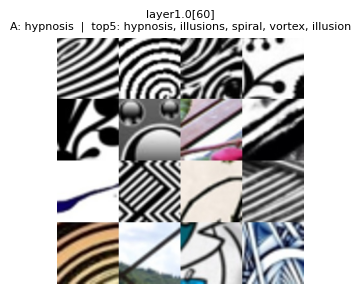

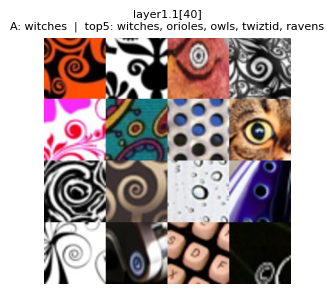

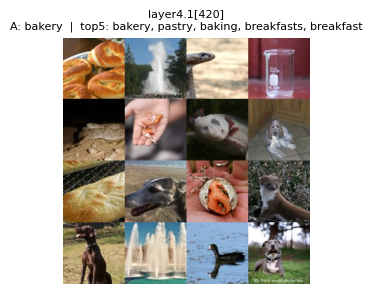

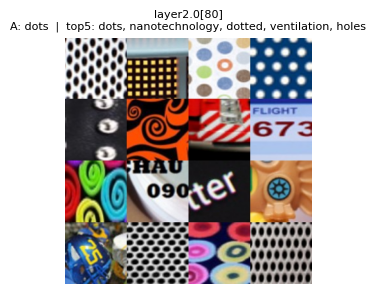

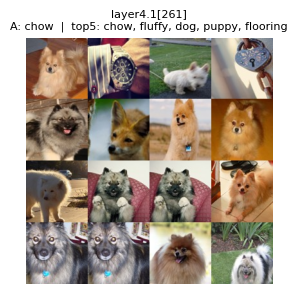

In [ ]:
def show_label(stage, channel):
    row = dfA[(dfA.stage == stage) & (dfA.channel == channel)].iloc[0]
    grid = RESULTS / "exemplars" / "grids" / f"{stage.replace('.','_')}_{channel:04d}.jpg"
    import matplotlib.pyplot as plt
    from PIL import Image
    plt.figure(figsize=(3.2, 3.2)); plt.imshow(Image.open(grid)); plt.axis("off")
    plt.title(f"{stage}[{channel}]\nA: {row.label_A}  |  top5: {', '.join(row.top5_A)}", fontsize=8)
    plt.show()

# a few known ones from week 2
for s, c in [("layer1.0", 60), ("layer1.1",40), ("layer4.1", 420), ("layer2.0", 80), ("layer4.1", 261)]:
    show_label(s, c)


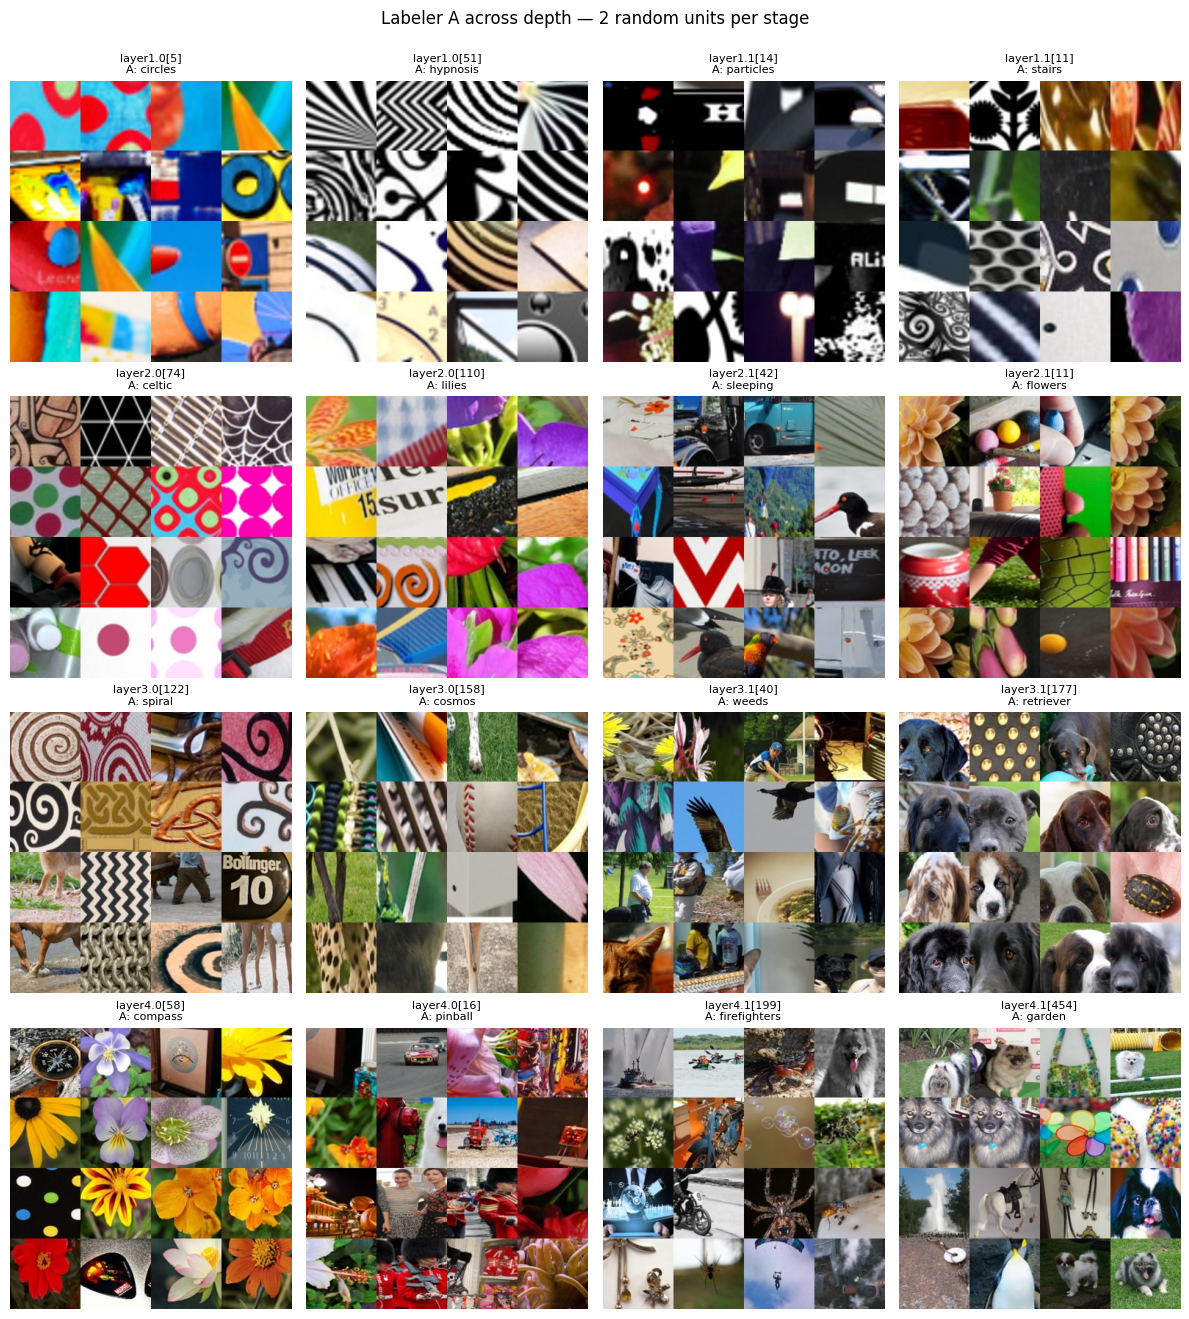

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

def show_units(units, ncols=4, title=""):
    n = len(units)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 3.3))
    for ax, (s, c) in zip(np.atleast_1d(axes).flat, units):
        row = dfA[(dfA.stage == s) & (dfA.channel == c)].iloc[0]
        grid = RESULTS / "exemplars" / "grids" / f"{s.replace('.','_')}_{c:04d}.jpg"
        ax.imshow(Image.open(grid)); ax.axis("off")
        ax.set_title(f"{s}[{c}]\nA: {row.label_A}", fontsize=8)
    for ax in np.atleast_1d(axes).flat[n:]:
        ax.axis("off")
    fig.suptitle(title, y=1.0, fontsize=12)
    plt.tight_layout(); plt.show()

# two random units from each of the 8 stages, seeded so it's reproducible
rng = np.random.default_rng(3)
spread = []
for s in STAGES:
    for c in rng.choice(STAGE_C[s], 2, replace=False):
        spread.append((s, int(c)))
show_units(spread, ncols=4, title="Labeler A across depth — 2 random units per stage")

## 6. Labeler B — free-form VLM captions (400-unit subsample)

A stratified subsample of 50 units per stage (400 total). We show the VLM each unit's 4x4
exemplar grid and ask for a 3-5 word label. Default model: moondream2 (Apache-2.0, T4-
friendly, loaded via transformers on CUDA). Swap `VLM_NAME` to try Gemma-3-4B etc.
Resumable: results append to a JSON keyed by unit, so a disconnect costs only the current
unit.

In [ ]:
# ---- choose the subsample (fixed by seed) ----
rng = np.random.default_rng(CONFIG["seed"])
SUBSAMPLE = []
for s in STAGES:
    chans = rng.choice(STAGE_C[s], size=min(50, STAGE_C[s]), replace=False)
    SUBSAMPLE += [(s, int(c)) for c in chans]
print("subsample size:", len(SUBSAMPLE))

VLM_NAME = "Qwen/Qwen2.5-VL-3B-Instruct"     # <- swap here if needed, e.g. "google/gemma-3-4b-it"
PROMPT = ("These image patches all activate the same vision feature. "
          "Reply with ONLY a short noun phrase (2-4 words) naming the shared visual concept. "
          "No sentence, no explanation, no trailing words. Examples: 'black and white stripes', "
          "'dog faces', 'honeycomb texture'.")


subsample size: 400


In [ ]:
!pip install transformers accelerate einops -q

In [ ]:

from transformers import AutoModelForCausalLM, AutoTokenizer
from PIL import Image

def load_vlm(name):
# generic HF vision-chat fallback (works for Gemma-3, Qwen2.5-VL, etc.)
      from transformers import AutoProcessor, AutoModelForImageTextToText
      proc = AutoProcessor.from_pretrained(name)
      m = AutoModelForImageTextToText.from_pretrained(
          name, torch_dtype=torch.float16, device_map=device).eval()
      def caption(img):
          msgs = [{"role": "user", "content": [
              {"type": "image", "image": img}, {"type": "text", "text": PROMPT}]}]
          inp = proc.apply_chat_template(msgs, add_generation_prompt=True,
                                          tokenize=True, return_dict=True,
                                          return_tensors="pt").to(device)
          out = m.generate(**inp, max_new_tokens=20, do_sample=False)
          return proc.decode(out[0][inp["input_ids"].shape[1]:],
                              skip_special_tokens=True).strip()
      return caption

caption_fn = load_vlm(VLM_NAME)
print("loaded", VLM_NAME)


preprocessor_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/1.05k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.37k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/5.70k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]

loaded Qwen/Qwen2.5-VL-3B-Instruct


In [ ]:
LABELS_B_PATH = RESULTS / "labels" / "labels_B.json"
labelsB = json.load(open(LABELS_B_PATH)) if LABELS_B_PATH.exists() else {}

t0 = time.time()
for i, (s, c) in enumerate(SUBSAMPLE):
    key = f"{s}_{c}"
    if key in labelsB:
        continue
    grid = RESULTS / "exemplars" / "grids" / f"{s.replace('.','_')}_{c:04d}.jpg"
    try:
        cap = caption_fn(Image.open(grid).convert("RGB"))
    except Exception as e:
        cap = f"[error: {e}]"
    labelsB[key] = {"stage": s, "channel": c, "label_B": cap, "model": VLM_NAME}
    if (i + 1) % 20 == 0:
        json.dump(labelsB, open(LABELS_B_PATH, "w"), indent=1)
        print(f"  {i+1}/{len(SUBSAMPLE)} captioned, {time.time()-t0:.0f}s | last: {cap!r}")
json.dump(labelsB, open(LABELS_B_PATH, "w"), indent=1)
print("Labeler B done:", len(labelsB), "captions,", f"{time.time()-t0:.0f}s")


Labeler B done: 400 captions, 0s


## 7. Quick look at A vs B on the subsample (preview of H4)

Merge the two label tables on the 400 shared units and eyeball agreement. This is not the
H4 analysis (that comes with scores in week 5) — just a first read on where a fixed
vocabulary and a free-form caption say the same thing or diverge.

In [ ]:
rowsB = [{"stage": v["stage"], "channel": v["channel"], "label_B": v["label_B"]}
         for v in labelsB.values()]
dfB = pd.DataFrame(rowsB)
merged = dfA.merge(dfB, on=["stage", "channel"], how="inner")[
    ["stage", "channel", "label_A", "label_B"]]
print(f"{len(merged)} units labelled by both\n")
import pandas as pd
with pd.option_context("display.max_rows", 40, "display.max_colwidth", 40):
    display(merged.sort_values(["stage", "channel"]).head(40))


400 units labelled by both



,stage,channel,label_A,label_B
0,layer1.0,0,ambulance,Stripes and patterns
1,layer1.0,1,pitbull,Colorful patterns and textures.
2,layer1.0,4,spheres,Skull and crossbones.
3,layer1.0,5,circles,Colorful shapes and patterns
4,layer1.0,7,dots,Food and drink branding.
5,layer1.0,8,rumsfeld,Urban landscape
6,layer1.0,9,stripes,Colorful patterns
7,layer1.0,10,hypnosis,Digital glitch patterns
8,layer1.0,12,stains,Abstract shapes and patterns
9,layer1.0,13,illusions,Pattern recognition


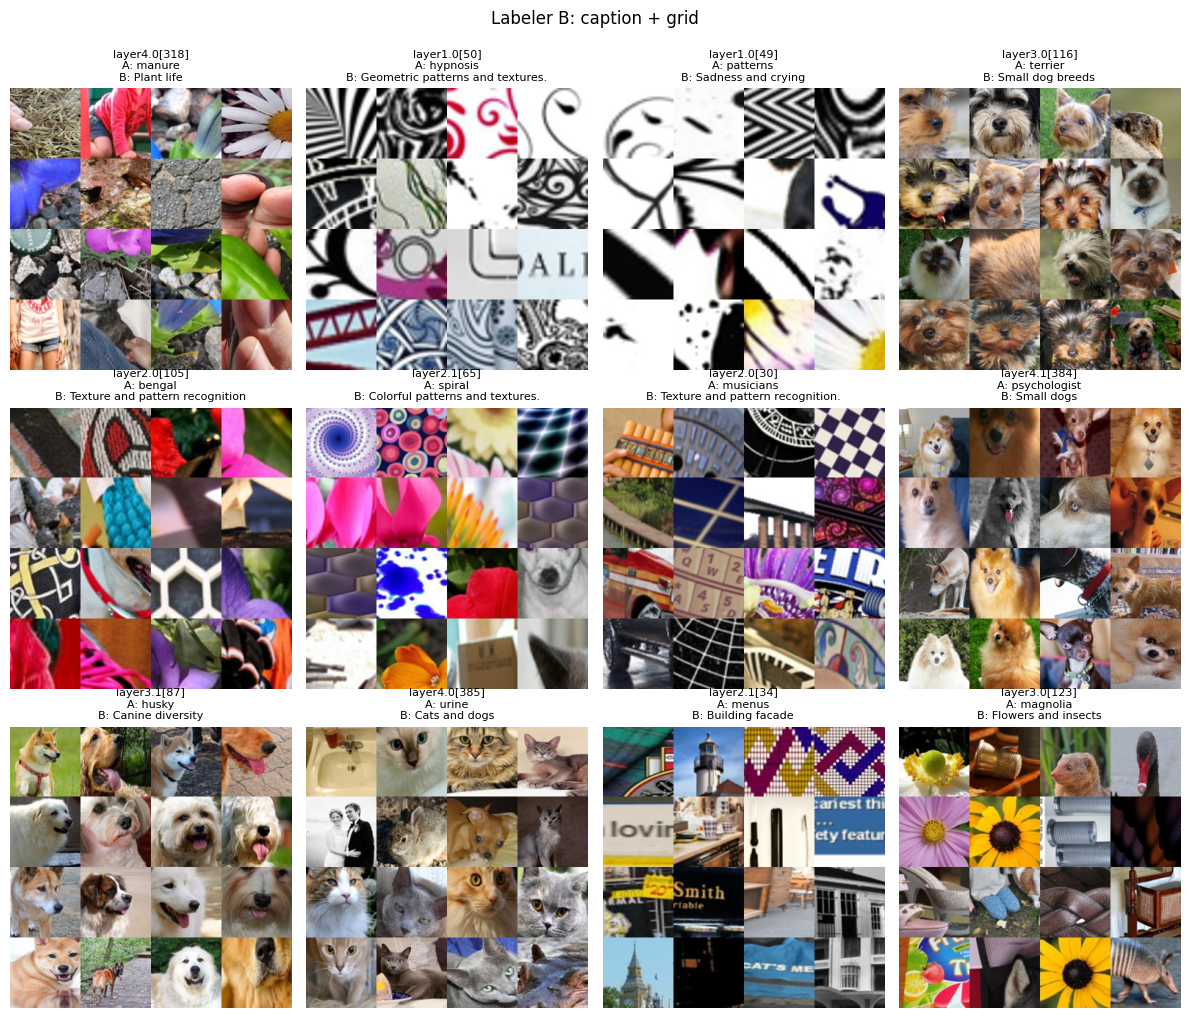

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

def show_B(units, ncols=4, title="Labeler B: caption + grid"):
    n = len(units)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 3.4))
    for ax, (s, c) in zip(np.atleast_1d(axes).flat, units):
        key = f"{s}_{c}"
        capB = labelsB.get(key, {}).get("label_B", "(no caption)")
        rowA = dfA[(dfA.stage == s) & (dfA.channel == c)].iloc[0]
        grid = RESULTS / "exemplars" / "grids" / f"{s.replace('.','_')}_{c:04d}.jpg"
        ax.imshow(Image.open(grid)); ax.axis("off")
        ax.set_title(f"{s}[{c}]\nA: {rowA.label_A}\nB: {capB}", fontsize=8)
    for ax in np.atleast_1d(axes).flat[n:]:
        ax.axis("off")
    fig.suptitle(title, y=1.0, fontsize=12)
    plt.tight_layout(); plt.show()

# show a random spread from the subsample, both labels under each grid
subs = list(labelsB.keys())
rng = np.random.default_rng(5)
pick = [tuple([p.rsplit("_", 1)[0], int(p.rsplit("_", 1)[1])])
        for p in rng.choice(subs, 12, replace=False)]
show_B(pick, ncols=4)